## 25 — Cited Papers Exploratory Analysis

Eight exploratory plots on the cited papers dataset collected in notebook 24.

**Inputs:**
- `data/matched/cited_papers.csv` — 26,921 unique papers cited by award papers
- `data/matched/award_to_cited_edges.csv` — 34,417 award→cited edges

**Plots:**
1. Publication year distribution of cited papers
2. Citation count distribution (log scale)
3. Author count per cited paper
4. Top 20 most-shared cited papers (highest `cited_by_n_award_papers`)
5. Distribution of `cited_by_n_award_papers`
6. Top fields (`top_field`)
7. Source type breakdown (`source_type`)
8. Reference age at citation time (`award_year - publication_year`)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

# Print-safe black-first style: black for single-series, shading+hatch for differentiation
plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : 'black',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : False,
    'grid.color'       : '#dddddd',
    'grid.linewidth'   : 0.6,
    'font.family'      : 'Arial',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'legend.frameon'   : True,
    'legend.edgecolor' : '#cccccc',
})

HATCHES = ['///', 'xxx', '...', '\\\\', '+++', '---', '|||']
# black first; progressively lighter shades used only when differentiating multiple series
GREYS   = ['black', '#444', '#777', '#999', '#bbb', '#ddd']
MARKERS = ['o', 's', 'D', '^', 'v', 'P', '*']

DATA = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories\data\matched')
FIG  = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories\figures')
FIG.mkdir(parents=True, exist_ok=True)

cited  = pd.read_csv(DATA / 'cited_papers.csv')
edges  = pd.read_csv(DATA / 'award_to_cited_edges.csv')

print(f'cited_papers : {len(cited):,} rows  |  cols: {list(cited.columns)}')
print(f'edges        : {len(edges):,} rows  |  cols: {list(edges.columns)}')

cited_papers : 26,921 rows  |  cols: ['openalex_id', 'doi', 'title', 'publication_year', 'publication_date', 'type', 'cited_by_count', 'is_retracted', 'is_oa', 'source_id', 'source_name', 'source_type', 'source_issn', 'author_ids', 'author_names', 'author_positions', 'author_count', 'first_author_institution', 'top_topic', 'top_field', 'counts_by_year', 'cited_by_award_papers', 'cited_by_n_award_papers']
edges        : 34,417 rows  |  cols: ['award_paper_id', 'award_year', 'award_conference', 'cited_paper_id']


### Plot 1 — Publication year distribution of cited papers

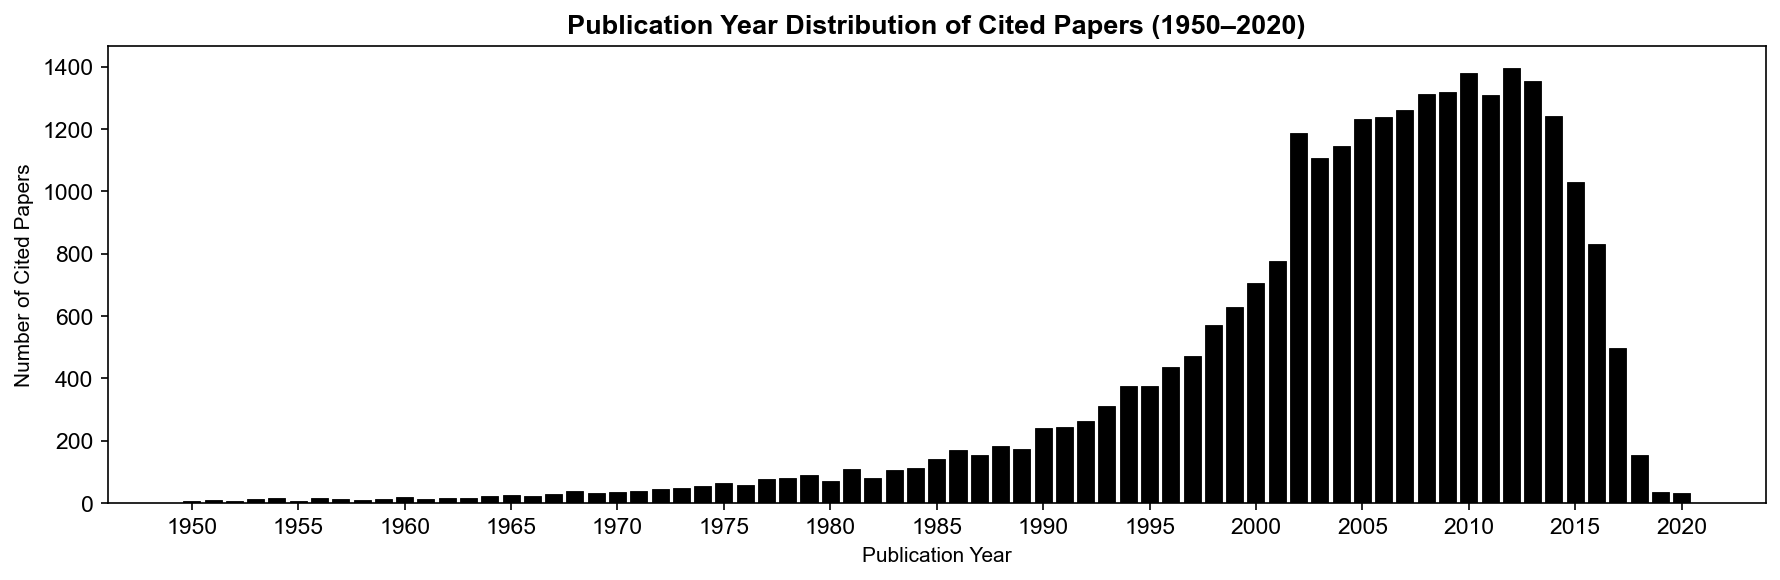

Peak year: 2012 (1,397 papers)


In [29]:
yr = cited['publication_year'].dropna().astype(int)
yr_counts = yr[(yr >= 1950) & (yr <= 2020)].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yr_counts.index, yr_counts.values,
       color='black', edgecolor='black', linewidth=0.4, width=0.8)
ax.set_xlabel('Publication Year')
ax.set_ylabel('Number of Cited Papers')
ax.set_title('Publication Year Distribution of Cited Papers (1950–2020)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.savefig(FIG / 'p25_01_pub_year.png', dpi=150)
plt.show()
print(f'Peak year: {yr_counts.idxmax()} ({yr_counts.max():,} papers)')

### Plot 2 — Citation count distribution (log scale)

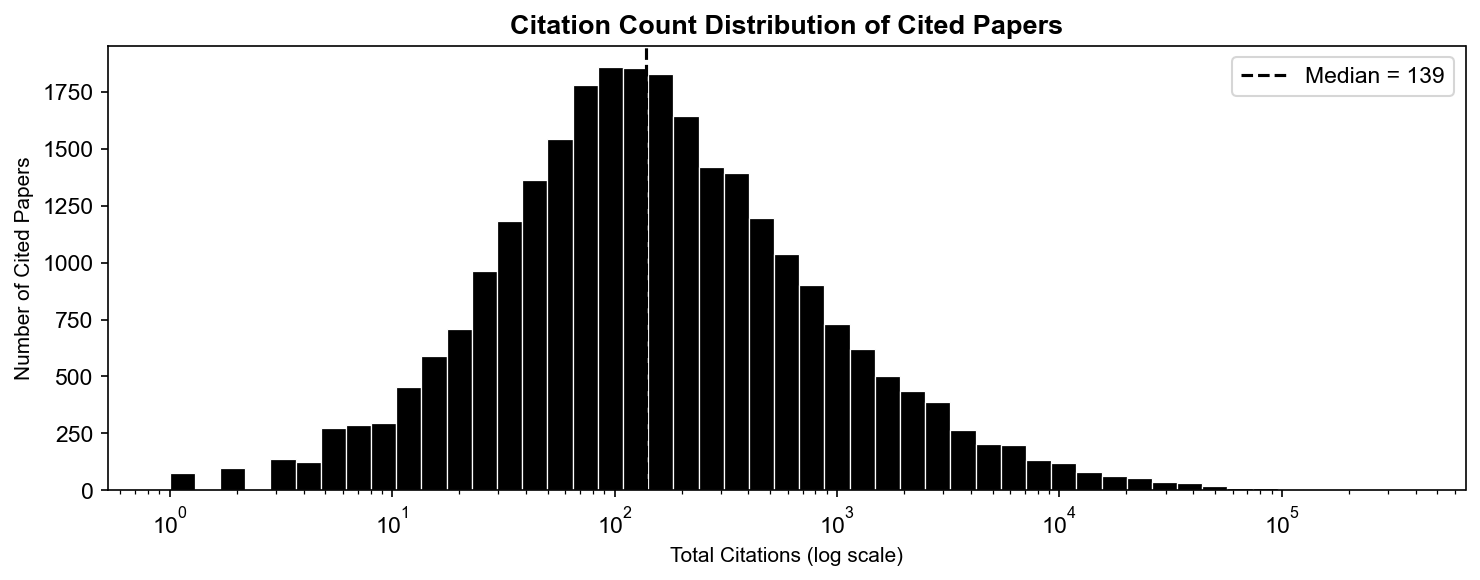

count     26921.0
mean        859.2
std        4556.5
min           1.0
25%          51.0
50%         139.0
75%         427.0
max      352953.0
Name: cited_by_count, dtype: float64


In [ ]:
cbc = cited['cited_by_count'].dropna().astype(int)
cbc = cbc[cbc > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.logspace(0, np.log10(cbc.max()), 50)
ax.hist(cbc, bins=bins, color='black', edgecolor='white', linewidth=0.6)
ax.set_xscale('log')
ax.set_xlabel('Total Citations (log scale)')
ax.set_ylabel('Number of Cited Papers')
ax.set_title('Citation Count Distribution of Cited Papers')
med = cbc.median()
ax.axvline(med, color='gray', linestyle='--', linewidth=1.5, label=f'Median = {med:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'p25_02_citation_dist.png', dpi=150)
plt.show()
print(cbc.describe().round(1))

X-axis (Total Citations, log scale) = how many times a referenced paper has been cited in total across all of science. It's the paper's lifetime citation count, shown on a log scale because the range spans from 1 to 100,000.

Y-axis (Number of Cited Papers) = how many papers in our collected dataset have that citation count. It's just a frequency count — "how many of our referenced papers fall into this citation bucket."

So a bar at x=100, y=1800 means: 1,800 papers in our reference collection have around 100 total citations.

 The referenced papers are high-quality and well-integrated into the literature, which is expected given that award papers themselves are top-tier. This also validates that the `referenced_works` data pulled from OpenAlex is sensible before feeding it into the CD5 computation.

### Plot 3 — Author count per cited paper

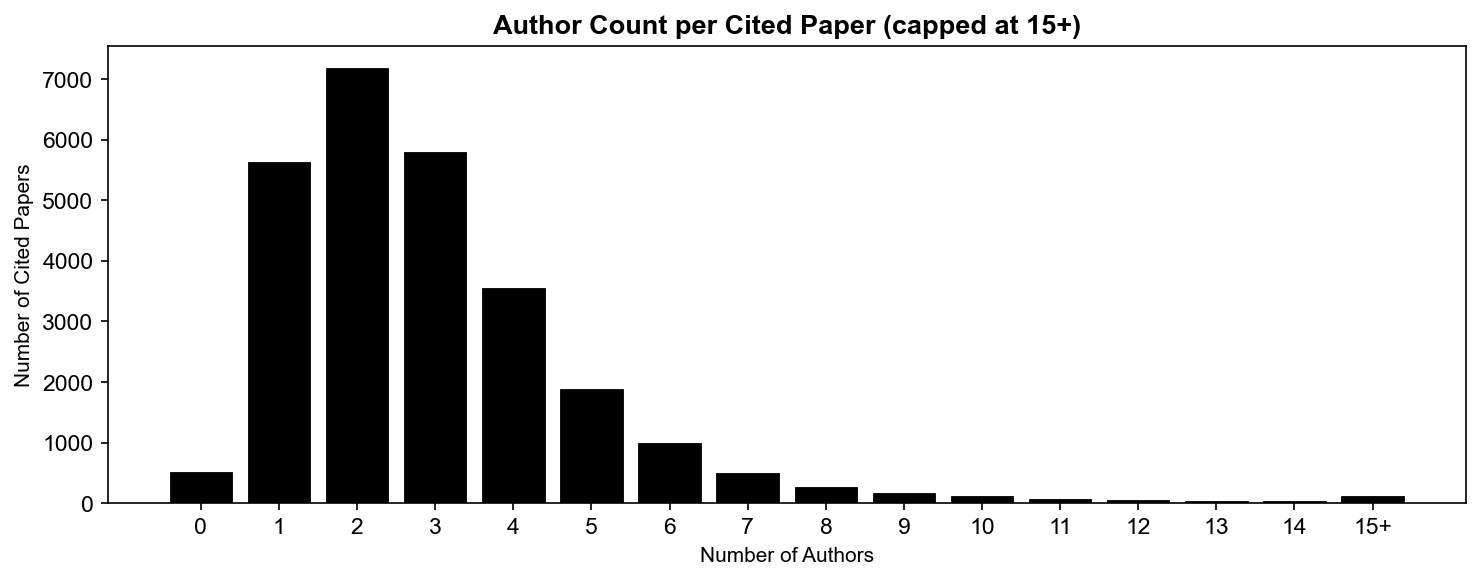

Median authors: 3.0  |  Mean: 3.0


In [31]:
ac = cited['author_count'].dropna().astype(int)
ac_cap = ac.clip(upper=15)
counts = ac_cap.value_counts().sort_index()
labels = [str(i) if i < 15 else '15+' for i in counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, counts.values,
       color='black', edgecolor='black', linewidth=0.4)
ax.set_xlabel('Number of Authors')
ax.set_ylabel('Number of Cited Papers')
ax.set_title('Author Count per Cited Paper (capped at 15+)')
plt.tight_layout()
plt.savefig(FIG / 'p25_03_author_count.png', dpi=150)
plt.show()
print(f'Median authors: {ac.median():.1f}  |  Mean: {ac.mean():.1f}')

### Plot 4 — Top 20 most-shared cited papers

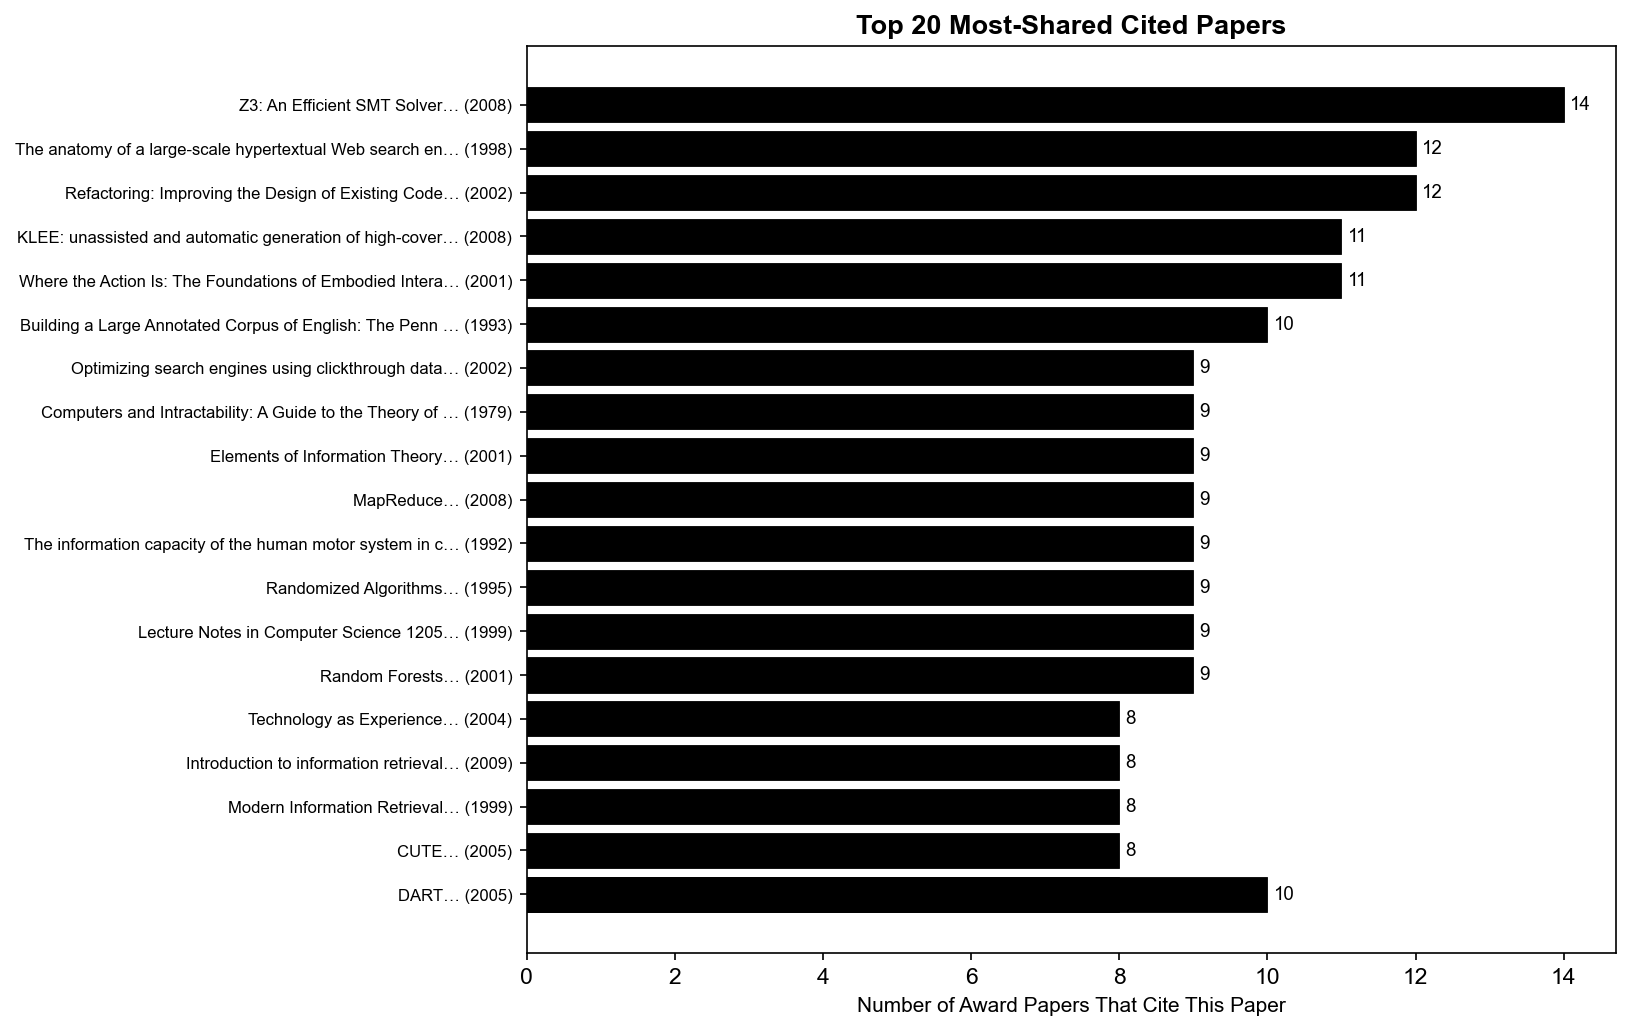

In [32]:
top20 = (
    cited[['title', 'cited_by_n_award_papers', 'publication_year']]
    .dropna(subset=['cited_by_n_award_papers'])
    .nlargest(20, 'cited_by_n_award_papers')
    .copy()
)
top20['label'] = top20.apply(
    lambda r: f"{str(r['title'])[:55]}… ({int(r['publication_year']) if pd.notna(r['publication_year']) else '?'})",
    axis=1
)
top20 = top20.sort_values('cited_by_n_award_papers')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['label'], top20['cited_by_n_award_papers'],
               color='black', edgecolor='black', linewidth=0.4)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Award Papers That Cite This Paper')
ax.set_title('Top 20 Most-Shared Cited Papers')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(FIG / 'p25_04_top20_shared.png', dpi=150)
plt.show()

### Plot 5 — Distribution of cited_by_n_award_papers

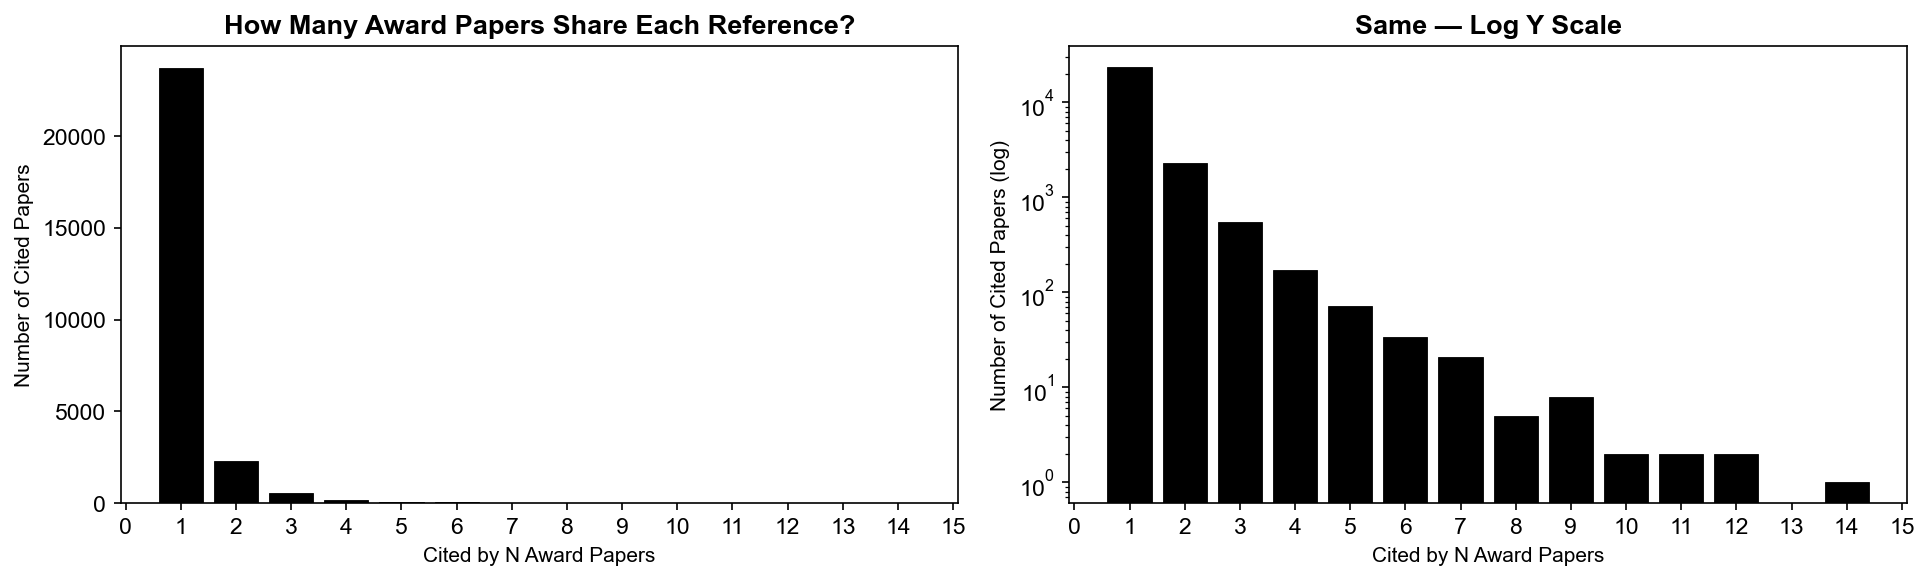

cited_by_n_award_papers
1     23737
2      2308
3       556
4       174
5        71
6        34
7        21
8         5
9         8
10        2
11        2
12        2
14        1


In [33]:
n_dist = cited['cited_by_n_award_papers'].dropna().astype(int).value_counts().sort_index()
n_dist_cap = n_dist[n_dist.index <= 15]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(n_dist_cap.index, n_dist_cap.values,
            color='black', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('Cited by N Award Papers')
axes[0].set_ylabel('Number of Cited Papers')
axes[0].set_title('How Many Award Papers Share Each Reference?')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].bar(n_dist_cap.index, n_dist_cap.values,
            color='black', edgecolor='black', linewidth=0.4)
axes[1].set_yscale('log')
axes[1].set_xlabel('Cited by N Award Papers')
axes[1].set_ylabel('Number of Cited Papers (log)')
axes[1].set_title('Same — Log Y Scale')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig(FIG / 'p25_05_cited_by_n_dist.png', dpi=150)
plt.show()
print(n_dist.head(15).to_string())

### Plot 6 — Top fields (top_field)

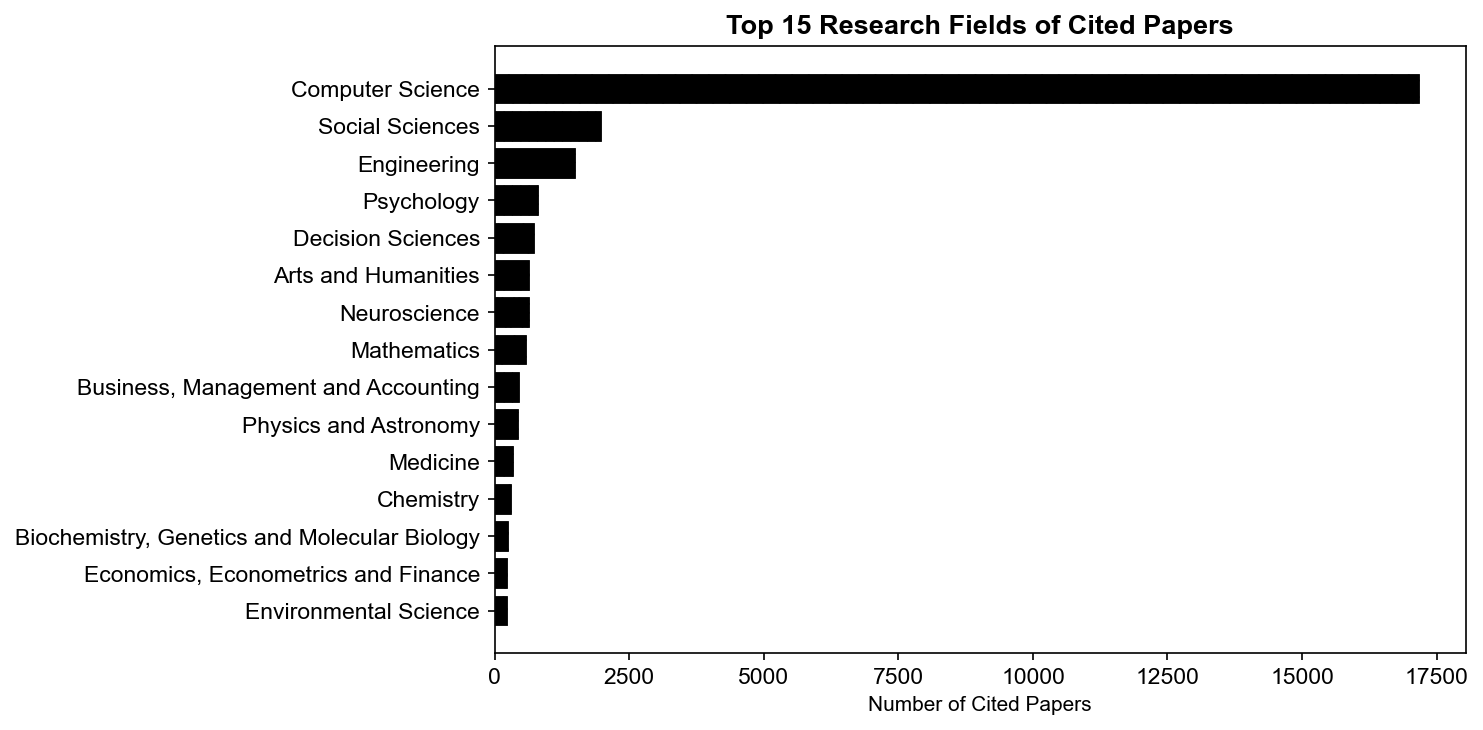

Papers with no field: 29 (0.1%)


In [34]:
fields = (
    cited['top_field']
    .dropna()
    .replace('', np.nan)
    .dropna()
    .value_counts()
    .head(15)
)
fields_sorted = fields.sort_values()

# Multiple categories: differentiate with hatches on a black base
n = len(fields_sorted)
bar_hatches = [HATCHES[i % len(HATCHES)] for i in range(n)]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, val) in enumerate(zip(fields_sorted.index, fields_sorted.values)):
    ax.barh(label, val, color='black', edgecolor='black',
            linewidth=0.4, hatch=bar_hatches[i])
ax.set_xlabel('Number of Cited Papers')
ax.set_title('Top 15 Research Fields of Cited Papers')
plt.tight_layout()
plt.savefig(FIG / 'p25_06_top_fields.png', dpi=150)
plt.show()
missing = cited['top_field'].isna().sum() + (cited['top_field'] == '').sum()
print(f'Papers with no field: {missing:,} ({missing/len(cited)*100:.1f}%)')

### Plot 7 — Source type breakdown (source_type)

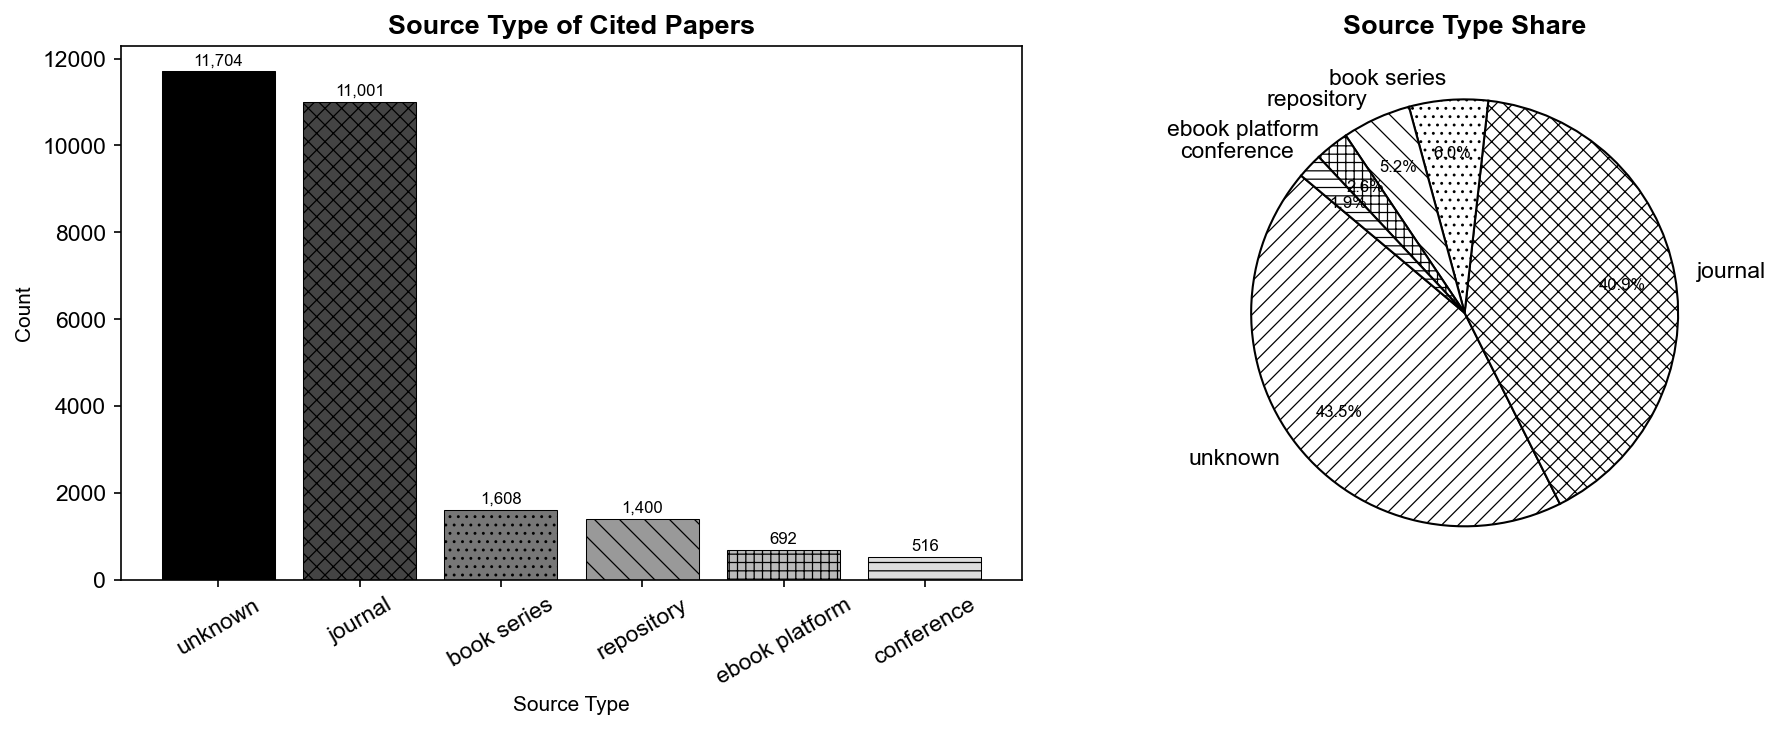

source_type
unknown           11704
journal           11001
book series        1608
repository         1400
ebook platform      692
conference          516
Name: count, dtype: int64


In [35]:
st = (
    cited['source_type']
    .fillna('unknown')
    .replace('', 'unknown')
    .value_counts()
)

n = len(st)
# Bar chart: black+shades+hatches for differentiation
cat_colors  = [GREYS[i % len(GREYS)]  for i in range(n)]
cat_hatches = [HATCHES[i % len(HATCHES)] for i in range(n)]
# Pie chart: white fill + unique hatch per wedge - avoids dark blobs blending together
pie_colors  = ['white'] * n

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (label, val) in enumerate(zip(st.index, st.values)):
    axes[0].bar(label, val, color=cat_colors[i], edgecolor='black',
                linewidth=0.5, hatch=cat_hatches[i])
    axes[0].text(i, val + 80, f'{val:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_xlabel('Source Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Source Type of Cited Papers')
axes[0].tick_params(axis='x', rotation=30)

wedges, texts, autotexts = axes[1].pie(
    st.values, labels=st.index, autopct='%1.1f%%', startangle=140,
    colors=pie_colors,
    wedgeprops=dict(edgecolor='black', linewidth=1.0),
    pctdistance=0.75
)
for i, w in enumerate(wedges):
    w.set_hatch(cat_hatches[i])
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title('Source Type Share')

plt.tight_layout()
plt.savefig(FIG / 'p25_07_source_type.png', dpi=150)
plt.show()
print(st)

### Plot 8 — Reference age at citation time (award_year − publication_year)

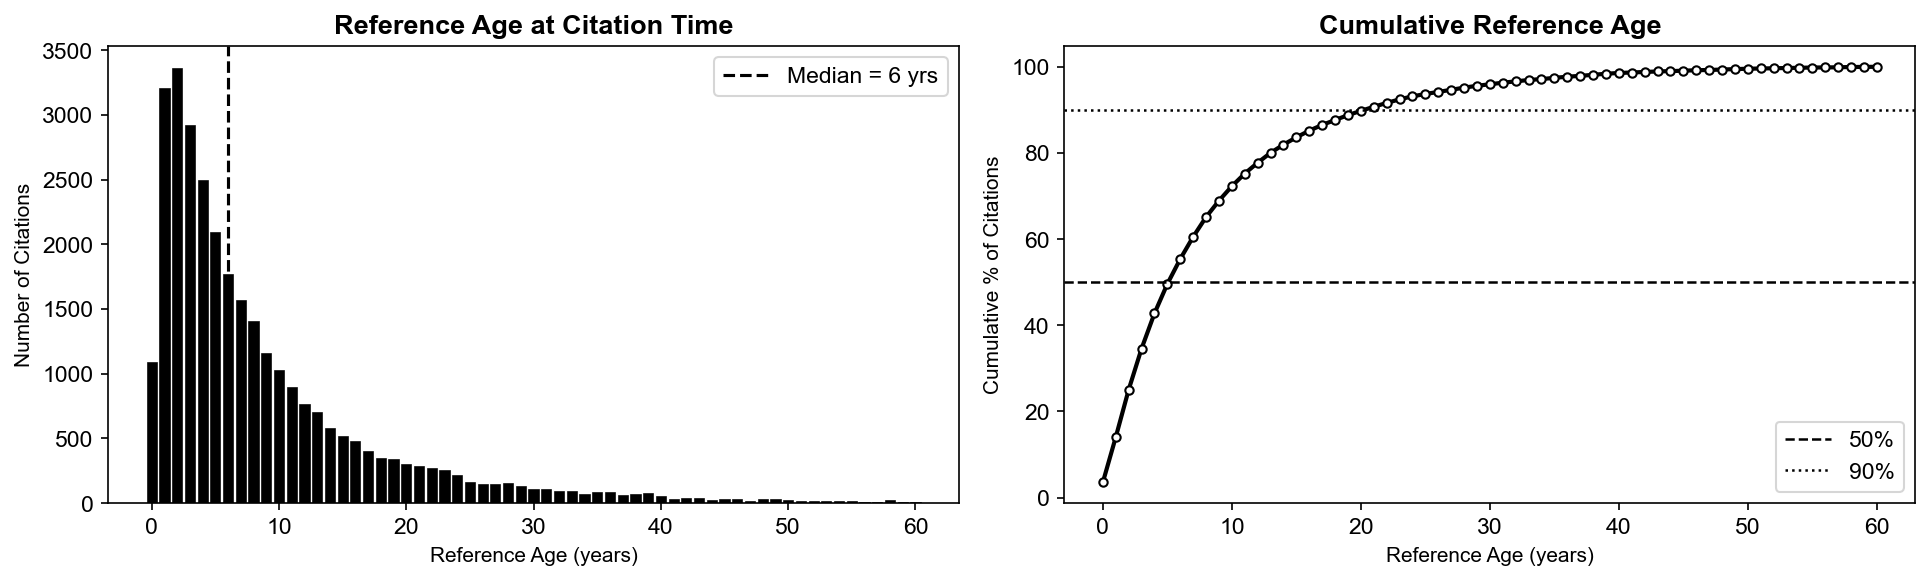

Median ref age: 6 yrs
90% of citations are to papers <= 21 years old


In [36]:
pub_yr = cited[['openalex_id', 'publication_year']].rename(columns={'openalex_id': 'cited_paper_id'})
edges_age = edges.merge(pub_yr, on='cited_paper_id', how='left')
edges_age['ref_age'] = edges_age['award_year'] - edges_age['publication_year']

age = edges_age['ref_age'].dropna()
age = age[(age >= 0) & (age <= 60)].astype(int)
age_counts = age.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(age_counts.index, age_counts.values,
            color='black', edgecolor='black', linewidth=0.3, width=0.8)
axes[0].set_xlabel('Reference Age (years)')
axes[0].set_ylabel('Number of Citations')
axes[0].set_title('Reference Age at Citation Time')
axes[0].axvline(age.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Median = {age.median():.0f} yrs')
axes[0].legend()

cum = age_counts.cumsum() / age_counts.sum() * 100
axes[1].plot(cum.index, cum.values, color='black', linewidth=2, marker=MARKERS[0],
             markersize=4, markerfacecolor='white', markeredgecolor='black')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1.2, label='50%')
axes[1].axhline(90, color='black', linestyle=':', linewidth=1.2, label='90%')
axes[1].set_xlabel('Reference Age (years)')
axes[1].set_ylabel('Cumulative % of Citations')
axes[1].set_title('Cumulative Reference Age')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / 'p25_08_ref_age.png', dpi=150)
plt.show()
print(f'Median ref age: {age.median():.0f} yrs')
print(f"90% of citations are to papers <= {age.quantile(0.9):.0f} years old")

Median reference age = 6 years means that when a paper in our dataset gets cited, half of its references are to works published within the last 6 years of that citation event.
